In [ ]:
from langgraph.graph import StateGraph, START, END
from spm_agent.states.pfm_experiment_state import PFMExperimentState

from spm_agent.nodes.preflight_node import preflight_node
from spm_agent.nodes.sync_status_node import sync_status_node
from spm_agent.nodes.scanner_calibration_node import get_scanner_calibrations_node
from spm_agent.nodes.decision_node import experiment_decision_node
from spm_agent.nodes.scan_plan_node import scan_plan_node
from spm_agent.nodes.scan_run_node import scan_run_node
from spm_agent.nodes.full_exp_analysis_node import full_exp_analysis_node


#

In [2]:
def route_by_decision(state):
    return state["decision_records"][-1].action

async def not_implemented_node(state):
    raise RuntimeError("loop branch not wired yet — decide chose 'loop'")

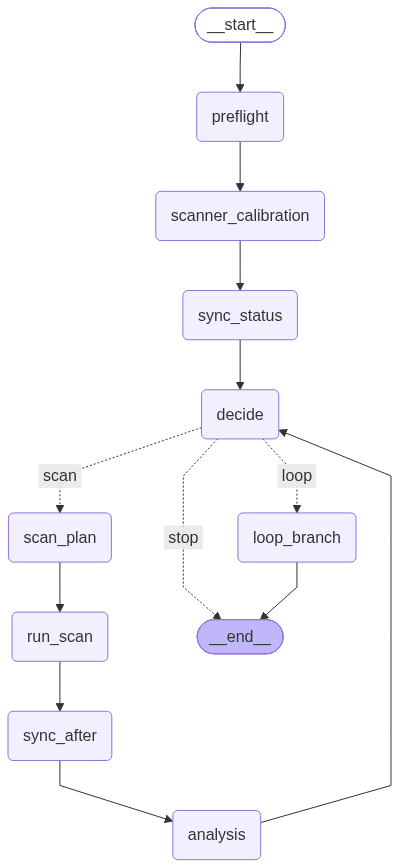

In [3]:
g = StateGraph(PFMExperimentState)
g.add_node("preflight", preflight_node)
g.add_node("scanner_calibration", get_scanner_calibrations_node)
g.add_node("sync_status", sync_status_node)
g.add_node("decide", experiment_decision_node)
g.add_node("scan_plan", scan_plan_node)
g.add_node("run_scan",    scan_run_node)
g.add_node("sync_after",  sync_status_node)     # same fn, second node name
g.add_node("analysis",    full_exp_analysis_node)
g.add_node("loop_branch", not_implemented_node)



g.add_edge(START, "preflight")
g.add_edge("preflight", "scanner_calibration")
g.add_edge("scanner_calibration", "sync_status")
g.add_edge("sync_status", "decide")

g.add_conditional_edges("decide", route_by_decision,
                        {"scan": "scan_plan", "loop": "loop_branch", "stop": END})

g.add_edge("scan_plan", "run_scan")
g.add_edge("run_scan", "sync_after")
g.add_edge("sync_after", "analysis")
g.add_edge("analysis", "decide")

fin_gr = g.compile()
fin_gr

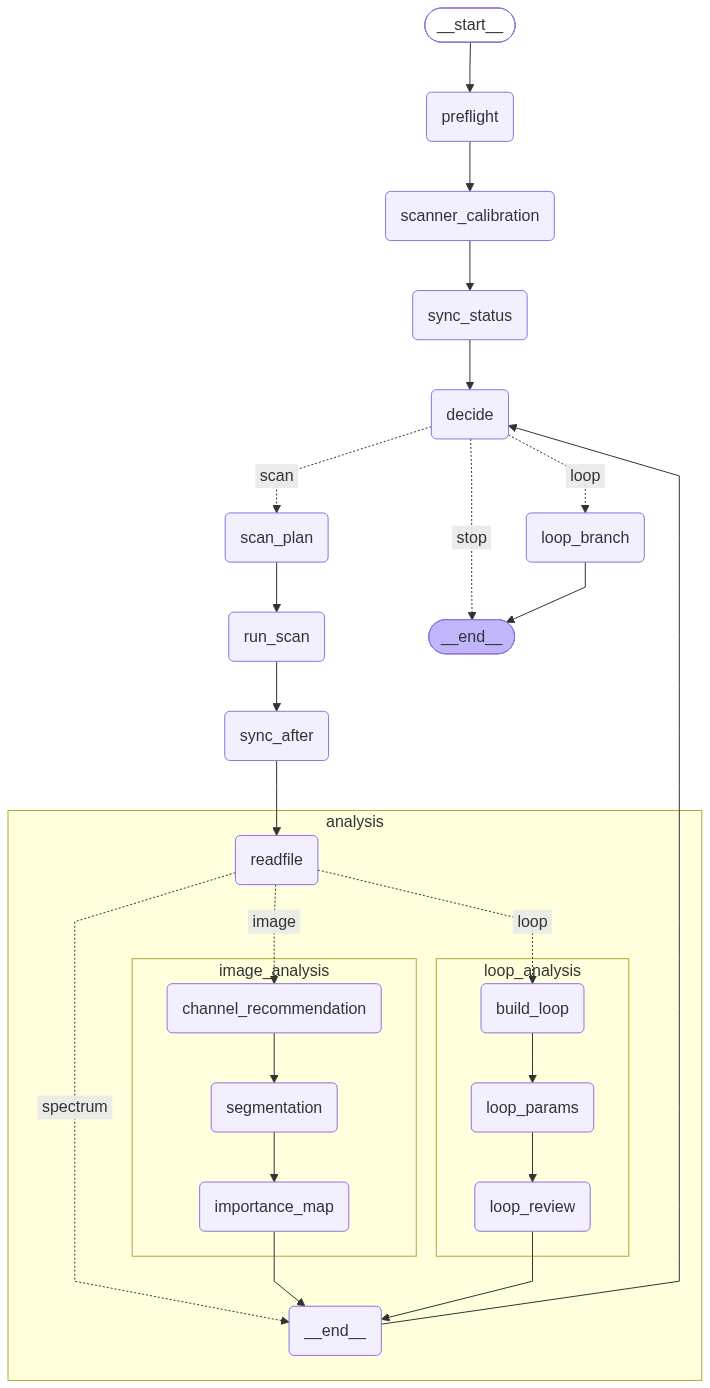

In [4]:
from IPython.display import Image
Image(fin_gr.get_graph(xray=True).draw_mermaid_png())

In [5]:
EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
]

EXPERIMENT_CONTEXT = (
        "This is Dual AC Resonance Tracking (DART) PFM experiment: two drive frequencies f1 and f2 straddle the "
        "contact resonance.  "
)

In [6]:
res = await fin_gr.ainvoke(
    {"experiment_tasks": EXPERIMENT_TASKS, "experiment_context": EXPERIMENT_CONTEXT})

[preflight] dir 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260811' | frame 7.0 um @ 256 px | f_DART 357.4 kHz | V_ac 0.80000001 V | feedback False
[scan_plan] first scan — operator settings adopted
[run_scan] starting — 7.00 um @ 256 px, 0.701 Hz (~365 s); args=instrument defaults
[run_scan] done — tuned=True -> C:\Users\Asylum User\Documents\Asylum Research Data\260811\PLZT_0005.ibw
image


RuntimeError: loop branch not wired yet — decide chose 'loop'